# Stage 4: Feature engineering and selection

This notebook works only with the training split. The goal is to create simple pre-call features, test whether they carry useful signal, and compare a shallow tree with all features against a smaller feature set.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_bank
from src.features import CATEGORICAL, NUMERIC, RAW_CATEGORICAL, RAW_NUMERIC, add_features
from src.pipeline import build

sns.set_theme(style='whitegrid')
pd.set_option('display.max_rows', 100)

## Split first and define the feature groups

In [2]:
bank = load_bank()
X = bank.drop(columns='y')
y = bank['y'].eq('yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Feature engineering is applied separately after the split.
X_train_features = add_features(X_train)
print(f'Training rows: {len(X_train):,}; test rows held back: {len(X_test):,}')
print('Raw numeric:', RAW_NUMERIC)
print('Raw categorical:', RAW_CATEGORICAL)
print('Model numeric:', NUMERIC)
print('Model categorical:', CATEGORICAL)
assert 'duration' not in NUMERIC + CATEGORICAL

Training rows: 36,168; test rows held back: 9,043
Raw numeric: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Raw categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Model numeric: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'prev_contacted', 'has_debt', 'balance_log']
Model categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'age_group']


### Observation and decision
The split happens before any feature-selection score or model fit. The test rows remain untouched because they are reserved for the final evaluation in the training script. The model sees the raw pre-call columns plus four deterministic engineered columns; `duration` is excluded from the lists.

## Why the engineered indicator features should help

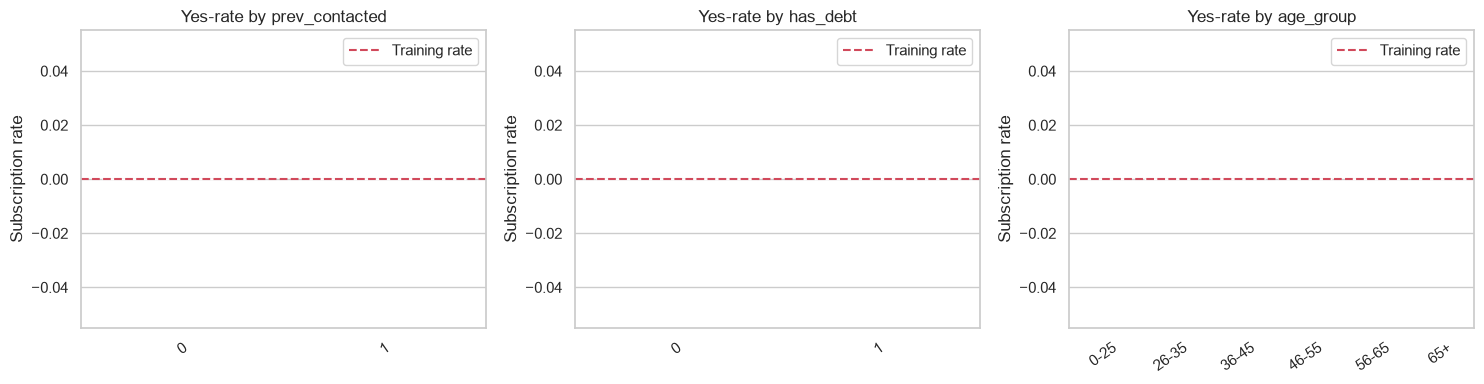

,prev_contacted,has_debt,age_group
0,0.0,0.0,NaN
0-25,NaN,NaN,0.0
1,0.0,0.0,NaN
26-35,NaN,NaN,0.0
36-45,NaN,NaN,0.0
46-55,NaN,NaN,0.0
56-65,NaN,NaN,0.0
65+,NaN,NaN,0.0


In [4]:
def yes_rate_by(frame, column):
    temp = frame.copy()
    temp[column] = temp[column].astype(str)
    temp['subscribed'] = temp['y'].eq('yes')

    return (
        temp.groupby(column, observed=False)['subscribed']
            .mean()
    )


train_for_rates = X_train_features.copy()
train_for_rates['y'] = y_train

train_for_rates['prev_contacted'] = (
    train_for_rates['pdays'].ne(-1).astype(int)
)

train_for_rates['has_debt'] = (
    train_for_rates['housing'].eq('yes') |
    train_for_rates['loan'].eq('yes')
).astype(int)

train_for_rates['age_group'] = train_for_rates['age_group'].astype(str)

rate_features = ['prev_contacted', 'has_debt', 'age_group']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis, column in zip(axes, rate_features):
    rates = yes_rate_by(train_for_rates, column).sort_values(
        ascending=False
    )

    sns.barplot(
        x=rates.index,
        y=rates.values,
        color='#2f6690',
        ax=axis
    )

    axis.axhline(
        y_train.eq('yes').mean(),
        color='#d1495b',
        linestyle='--',
        label='Training rate'
    )

    axis.set_title(f'Yes-rate by {column}')
    axis.set_xlabel('')
    axis.set_ylabel('Subscription rate')
    axis.tick_params(axis='x', rotation=35)
    axis.legend()

plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        column: yes_rate_by(train_for_rates, column)
        for column in rate_features
    })
)


### Observation and decision
`prev_contacted` captures whether the bank has a previous contact record, `has_debt` combines two related loan flags, and `age_group` allows a non-linear age effect. I would retain all three when their training-only yes-rates differ meaningfully from the training baseline; cross-validation will decide whether each difference generalises.

## Balance before and after the log transform

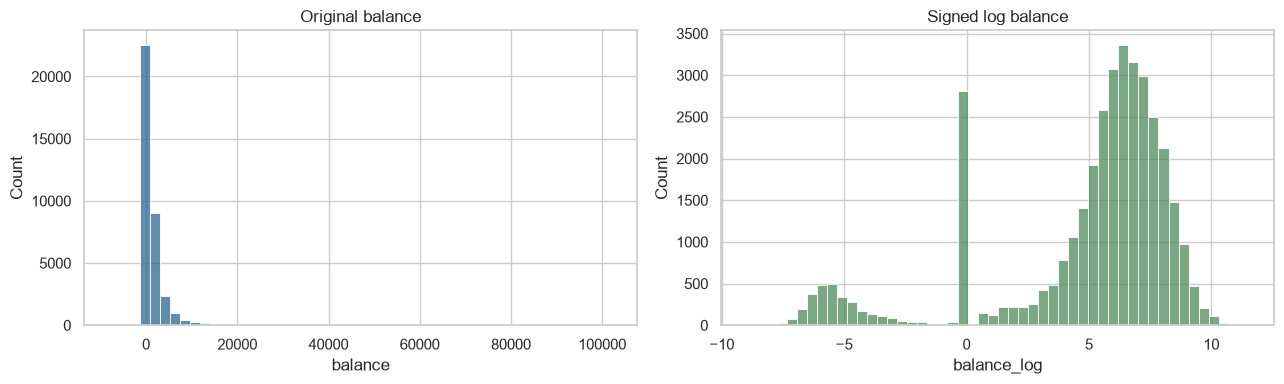

,min,50%,max,mean,std
balance,-8019.000000,451.000000,102127.000000,1365.493420,3068.543500
balance_log,-8.989694,6.113682,11.533982,4.895509,3.801214


In [5]:
balance_view = X_train_features[['balance', 'balance_log']].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(balance_view['balance'], bins=50, ax=axes[0], color='#2f6690')
axes[0].set_title('Original balance')
sns.histplot(balance_view['balance_log'], bins=50, ax=axes[1], color='#4f8a5b')
axes[1].set_title('Signed log balance')
plt.tight_layout()
plt.show()

display(balance_view.describe().T[['min', '50%', 'max', 'mean', 'std']])

### Observation and decision
Balances are usually skewed, so a signed log keeps the sign while compressing very large positive and negative values. This can make a linear or distance-based model less dominated by outliers. Tree models may gain less from the transform because splits do not require a normal scale, so it should be tested rather than assumed useful.

## Prepare training-only columns for feature selection

In [6]:
# One-hot encoding is used only to make the simple sklearn experiments numeric.
selection_data = X_train_features[NUMERIC + CATEGORICAL].copy()
for column in CATEGORICAL:
    selection_data[column] = selection_data[column].astype('string').fillna('unknown')
selection_data = pd.get_dummies(selection_data, columns=CATEGORICAL, dtype=float)
selection_data = selection_data.fillna(0.0)

print(f'Encoded training columns: {selection_data.shape[1]}')
selection_data.head()

Encoded training columns: 59


,age,balance,day,campaign,pdays,previous,prev_contacted,has_debt,balance_log,job_admin.,...,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,age_group_0-25,age_group_26-35,age_group_36-45,age_group_46-55,age_group_56-65,age_group_65+
24001,36,861,29,2,-1,0,0,0,6.759255,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
43409,24,4126,5,4,185,7,1,0,8.325306,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
20669,44,244,12,4,-1,0,0,1,5.501258,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
18810,48,0,31,11,-1,0,0,0,0.000000,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
23130,38,257,26,10,-1,0,0,0,5.552960,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


### Observation and decision
The selection experiment uses only the training partition. One-hot columns make categorical values usable by sklearn estimators; the production implementation should keep this transformation inside the shared pipeline so the encoder is fitted separately inside each training fold.

## Mutual information and random-forest permutation importance

In [7]:
mi_values = mutual_info_classif(selection_data, y_train, random_state=42)
mi_table = pd.DataFrame({'feature': selection_data.columns, 'mutual_information': mi_values})
mi_table = mi_table.sort_values('mutual_information', ascending=False)
display(mi_table.head(15))

rf_fit_x, rf_check_x, rf_fit_y, rf_check_y = train_test_split(
    selection_data, y_train, test_size=0.25, stratify=y_train, random_state=42
)
forest = build(RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1))
forest.fit(rf_fit_x, rf_fit_y)
permutation = permutation_importance(
    forest, rf_check_x, rf_check_y, scoring='average_precision',
    n_repeats=5, random_state=42, n_jobs=-1
)
permutation_table = pd.DataFrame({
    'feature': selection_data.columns,
    'permutation_importance': permutation.importances_mean,
}).sort_values('permutation_importance', ascending=False)
display(permutation_table.head(15))

,feature,mutual_information
51,poutcome_success,0.029907
4,pdays,0.025813
1,balance,0.023267
7,has_debt,0.021038
8,balance_log,0.019798
52,poutcome_unknown,0.018797
36,contact_unknown,0.016117
31,housing_yes,0.015205
0,age,0.013867
6,prev_contacted,0.013175


,feature,permutation_importance
51,poutcome_success,0.056549
4,pdays,0.017828
36,contact_unknown,0.014488
34,contact_cellular,0.014208
2,day,0.013175
44,month_mar,0.011707
0,age,0.011176
43,month_jun,0.010576
37,month_apr,0.010233
47,month_oct,0.007696


### Observation and decision
Mutual information can find non-linear dependence, while permutation importance asks how much a fitted forest's validation PR-AUC falls when one column is shuffled. I will trust features that are supported by both methods more than a feature that appears high in only one ranking. The forest is built through `build()` and the permutation check uses a held-back part of the training split.

## Shallow-tree feature selection experiment

In [8]:
importance_table = mi_table.merge(permutation_table, on='feature')
importance_table['mi_rank'] = importance_table['mutual_information'].rank(ascending=False, method='min')
importance_table['permutation_rank'] = importance_table['permutation_importance'].rank(ascending=False, method='min')
importance_table['average_rank'] = importance_table[['mi_rank', 'permutation_rank']].mean(axis=1)
importance_table = importance_table.sort_values(['average_rank', 'feature'])

top_count = max(1, len(selection_data.columns) // 2)
top_features = importance_table.head(top_count)['feature'].tolist()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_tree = build(DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42))
top_tree = build(DecisionTreeClassifier(max_depth=4, min_samples_leaf=50, random_state=42))
all_scores = cross_val_score(all_tree, selection_data, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
top_scores = cross_val_score(top_tree, selection_data[top_features], y_train, cv=cv, scoring='average_precision', n_jobs=-1)

cv_results = pd.DataFrame({
    'feature_set': ['all encoded features', 'top half by average rank'],
    'mean_pr_auc': [all_scores.mean(), top_scores.mean()],
    'std_pr_auc': [all_scores.std(), top_scores.std()],
})
display(cv_results)
print('Top selected features:', top_features)

,feature_set,mean_pr_auc,std_pr_auc
0,all encoded features,0.287174,0.016067
1,top half by average rank,0.287152,0.016078


Top selected features: ['poutcome_success', 'pdays', 'contact_unknown', 'contact_cellular', 'age', 'poutcome_unknown', 'month_mar', 'has_debt', 'day', 'prev_contacted', 'previous', 'campaign', 'month_may', 'balance_log', 'month_oct', 'housing_no', 'month_sep', 'job_blue-collar', 'month_apr', 'loan_no', 'month_dec', 'month_jun', 'age_group_0-25', 'balance', 'month_aug', 'housing_yes', 'age_group_26-35', 'marital_married', 'month_feb']


### Observation and decision
PR-AUC is the primary comparison because subscriptions are the minority class. If the top-half tree is similar to or better than the all-feature tree, the smaller set is easier to explain and less noisy. If it is clearly worse, keep the broader feature set and let regularisation and cross-validation control complexity.

## Leakage prevention

### Observation and decision
Split first, before feature selection or fitting. In the production pipeline, encoders, imputers, scalers, and any other transformers must be fitted inside the pipeline on each training fold only. `duration` is excluded because it is only known after the call and is strongly linked to the target. The engineered columns here use fixed row-level rules and learn no dataset-wide statistics. EDA and this notebook look at all rows only after the hold-out is defined; nothing is fitted in EDA or on the test set, so no statistics leak into modelling.

## Summary table

In [9]:
summary = pd.DataFrame({
    'feature group': [
        'prev_contacted', 'has_debt', 'age_group', 'balance_log',
        'raw categorical fields', 'duration'
    ],
    'decision': [
        'Keep if yes-rate and rankings support it',
        'Keep as a compact debt indicator',
        'Keep for a non-linear age effect',
        'Keep for models sensitive to skew; test for trees',
        'Keep and encode inside the pipeline',
        'Exclude: post-call leakage'
    ],
    'reason': [
        'Summarises whether prior contact history exists',
        'Combines housing and personal loan information',
        'Avoids forcing age to have one linear effect',
        'Compresses extreme balances while preserving sign',
        'Categorical rates show different client groups',
        'Unavailable when the call priority is needed'
    ],
})
display(summary)

print('Model-choice rule: compare candidates with stratified 5-fold PR-AUC, then inspect recall, precision, and ROC-AUC as supporting metrics.')

,feature group,decision,reason
0,prev_contacted,Keep if yes-rate and rankings support it,Summarises whether prior contact history exists
1,has_debt,Keep as a compact debt indicator,Combines housing and personal loan information
2,age_group,Keep for a non-linear age effect,Avoids forcing age to have one linear effect
3,balance_log,Keep for models sensitive to skew; test for trees,Compresses extreme balances while preserving sign
4,raw categorical fields,Keep and encode inside the pipeline,Categorical rates show different client groups
5,duration,Exclude: post-call leakage,Unavailable when the call priority is needed


Model-choice rule: compare candidates with stratified 5-fold PR-AUC, then inspect recall, precision, and ROC-AUC as supporting metrics.


### Observation and decision
The final decision is to keep deterministic pre-call features that are supported by training-only rates, mutual information, permutation importance, or cross-validation. The production model will use the selected columns through the same feature function and pipeline at training and serving time; `duration` remains permanently excluded.